In [1]:
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import torchvision.transforms as T
from torchvision.transforms import v2
import matplotlib.pyplot as plt

In [2]:
from unet.dataset import BriscDataset

In [3]:
dataset = BriscDataset(
    images_root="../../data/brisc2025",
    csv="../../data/brisc2025/metadata.csv",
    split="test",
    transforms=None
    )

In [ ]:
dataloader = DataLoader(dataset, batch_size=1)

data_iter = (iter(dataloader))

image, mask = next(data_iter)

In [5]:
image.shape, mask.shape

(torch.Size([1, 1, 512, 512]), torch.Size([1, 1, 512, 512]))

In [6]:
mask.max(), mask.min(), mask.unique(), mask.dtype

(tensor(1, dtype=torch.int32),
 tensor(0, dtype=torch.int32),
 tensor([0, 1], dtype=torch.int32),
 torch.int32)

In [ ]:
image, mask = next(data_iter)
image, mask = next(data_iter)
image, mask = next(data_iter)
image, mask = next(data_iter)
image, mask = next(data_iter)
image, mask = next(data_iter)


(tensor(1, dtype=torch.int32),
 tensor(0, dtype=torch.int32),
 tensor([0, 1], dtype=torch.int32),
 torch.int32)

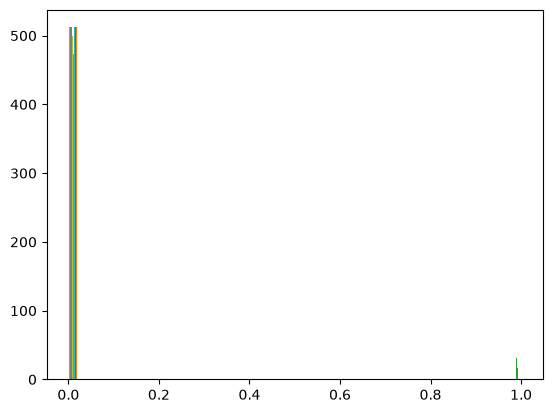

In [8]:
plt.hist(mask.squeeze().cpu().numpy(), bins=50)
plt.show()

In [9]:
mask_normalized = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])(mask)

print(mask_normalized.max(), mask_normalized.min())

mask_normalized[mask_normalized == 1] = 3
print(mask_normalized.max(), mask_normalized.min())

tensor(4.6566e-10) tensor(0.)
tensor(4.6566e-10) tensor(0.)


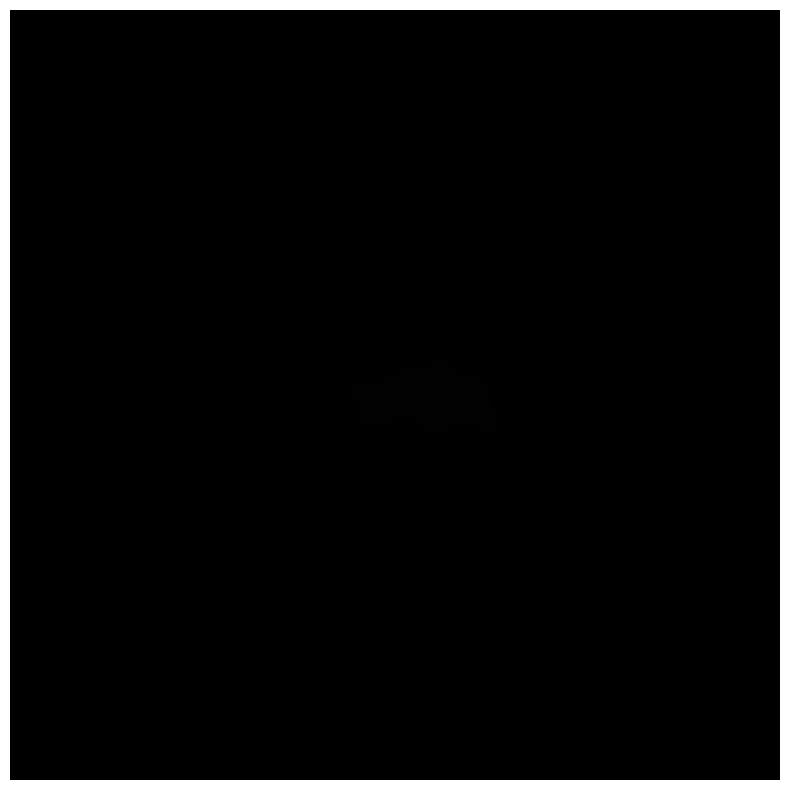

In [10]:
plt.figure(figsize=(10,10))

mask_img = T.ToPILImage()(mask.squeeze(0))
plt.imshow(mask_img, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
def _combine_mask_with_label(mask, label):
    mask = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
    ])(mask)

    mask[mask == 1] = label

    return mask

In [ ]:
print(mask.max(), mask.min())\

mask = _combine_mask_with_label(mask, 2)

print(mask.max(), mask.min())